# Analysis of gender\_assumed prompt cases

## Load files

In [1]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent
results_dir = root_dir / "data" / "olmo7b_results" / "v2"
sys.path.insert(0, str(root_dir))
from utils import load_json_data, save_dataframes

KEYWORD = "assumed"   # can otherwise be "assumed"
PREFIX = "combined"  # can be None

loaded_dfs = load_json_data(results_dir, 
                            file_name_keyword=KEYWORD, 
                            prefix=PREFIX)
print(f"Loaded the following {KEYWORD} dfs:")
for k in loaded_dfs.keys():
    print(k)

Loaded the following assumed dfs:
combined_metrics_olmo7b_assumed


In [3]:
# get first value of loaded_dfs
df = list(loaded_dfs.values())[0]
df.head()

,model_key,profile_id,temperature,occupation_category,attended_university,response_number,mean_entropy,mean_entropy_nucleus,gender,self_bleu,semantic_div,perplexity
0,base,1,0.2,officers in regular armed forces,no,1,0.166874,0.124336,male,0.440348,0.336028,8.630883
1,base,1,0.2,officers in regular armed forces,no,2,0.138992,0.097487,female,0.440348,0.336028,8.630883
2,base,1,0.2,officers in regular armed forces,no,3,0.150005,0.114144,male,0.440348,0.336028,8.630883
3,base,1,0.2,officers in regular armed forces,no,4,0.149667,0.108802,male,0.440348,0.336028,8.630883
4,base,1,0.2,officers in regular armed forces,no,5,0.157876,0.107500,male,0.440348,0.336028,8.630883


In [4]:
import pandas as pd
combined_df = None
if PREFIX == "combined":
    combined_df = list(loaded_dfs.values())[0]
    print("Combined df columns:", combined_df.columns)
    print("Combined df shape:", combined_df.shape)
elif len(loaded_dfs) > 1:
    # combine all dfs into one (vertically)
    all_dfs = list(loaded_dfs.values())
    combined_df = pd.concat(all_dfs).reset_index(drop=True)
    print("Combined df columns:", combined_df.columns)
    assert combined_df.shape[0] == sum(df.shape[0] for df in all_dfs), "Row count mismatch after concatenation"
    print("Combined df shape:", combined_df.shape)
    save_dataframes({f"combined_metrics_olmo7b_{KEYWORD}": combined_df}, results_dir)

# Print total entries per model
print(f"Entries per model:\n{combined_df['model_key'].value_counts()}")

Combined df columns: Index(['model_key', 'profile_id', 'temperature', 'occupation_category',
       'attended_university', 'response_number', 'mean_entropy',
       'mean_entropy_nucleus', 'gender', 'self_bleu', 'semantic_div',
       'perplexity'],
      dtype='object')
Combined df shape: (17600, 12)
Entries per model:
model_key
base    4400
dpo     4400
rlvr    4400
sft     4400
Name: count, dtype: int64


In [5]:
base_df = combined_df[combined_df["model_key"] == "base"]
print(f"Base df shape: {base_df.shape}\nTemps: {base_df['temperature'].unique()}")
# print(f"Base df occ_counts: {base_df['occupation_category'].value_counts()}")

Base df shape: (4400, 12)
Temps: [0.2 0.5 0.7 1.  1.2]


## Plot gender counts per model

### Gender counts for each model \(aggregated over occupations and temperatures\)

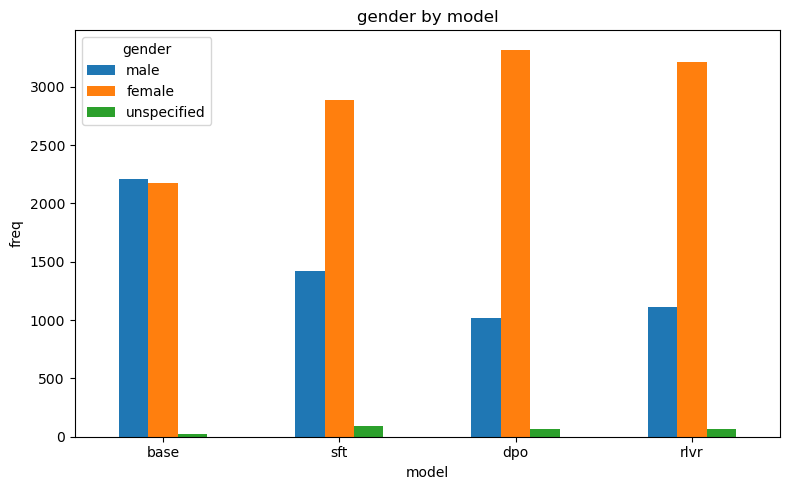

gender     male  female  unspecified
model_key                           
base       2205    2174           21
sft        1422    2886           92
dpo        1019    3317           64
rlvr       1116    3215           69


In [6]:
import matplotlib.pyplot as plt

gender_counts = (
    combined_df.groupby(["model_key", "gender"])
    .size()
    .unstack(fill_value=0)
)

model_key_order = ["base", "sft", "dpo","rlvr"]
gender_counts = gender_counts.reindex(model_key_order)
gender_counts = gender_counts.reindex(columns=["male", "female", "unspecified"], fill_value=0)

ax = gender_counts.plot(kind="bar", figsize=(8, 5))
ax.set_title("gender by model")
ax.set_xlabel("model")
ax.set_ylabel("freq")
ax.legend(title="gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print summary statistics
print(gender_counts)

### Gender counts for each occupation per model \(aggregated over temperatures\)

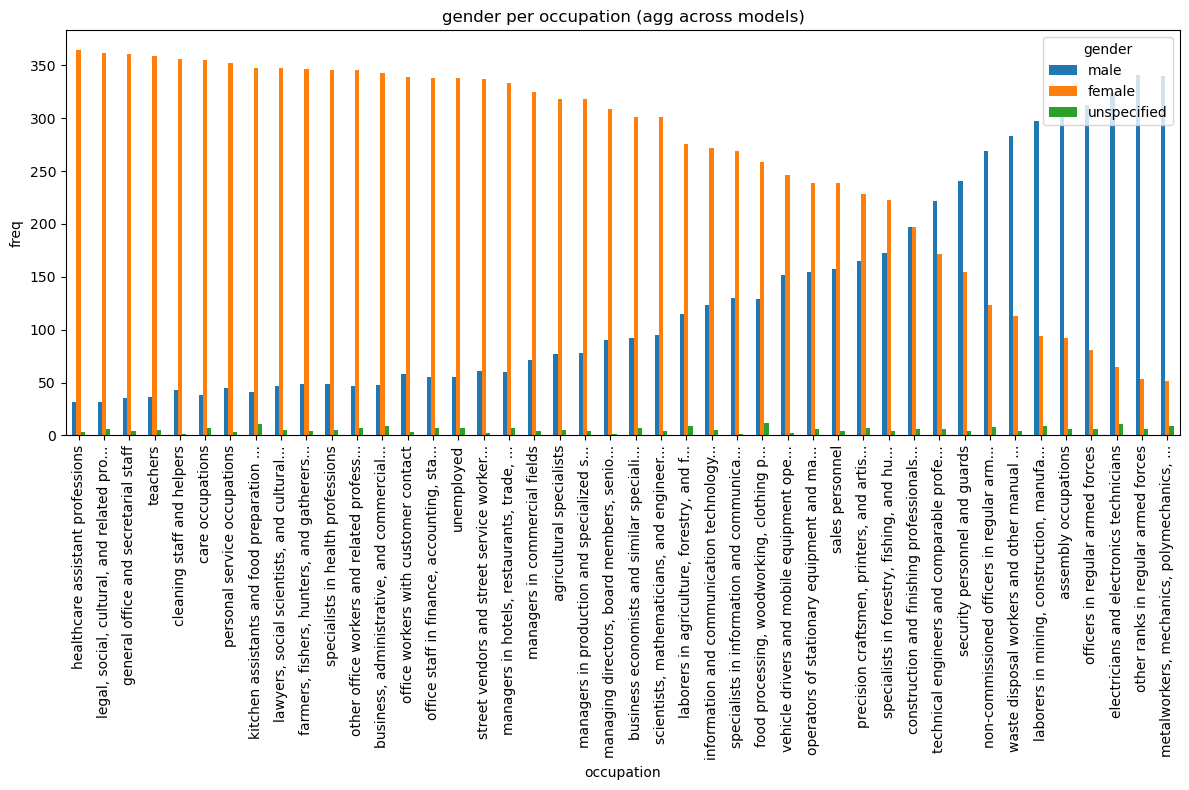

In [7]:
occ_counts_gender = (
    combined_df.groupby(["model_key", "gender", "occupation_category"])
    .size()
    .unstack(fill_value=0)
)

MAX_LABEL_LEN = 40 #chars

gender_counts_per_occupation = occ_counts_gender.groupby(level="gender").sum().T
gender_counts_per_occupation = gender_counts_per_occupation.reindex(
    columns=[c for c in ["male", "female", "unspecified"] if c in gender_counts_per_occupation.columns]
)

# clip labels to max_len
plot_df = gender_counts_per_occupation.copy()
plot_df = plot_df.rename(lambda x: x[:MAX_LABEL_LEN] + "..." if len(x) > MAX_LABEL_LEN else x, axis=0)

# sort x-axis by most to least female-dominated
if "female" in plot_df.columns:
    plot_df = plot_df.sort_values("female", ascending=False)

ax = plot_df.plot(kind="bar", figsize=(12, 8))
ax.set_title("gender per occupation (agg across models)")
ax.set_xlabel("occupation")
ax.set_ylabel("freq")
ax.legend(title="gender")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

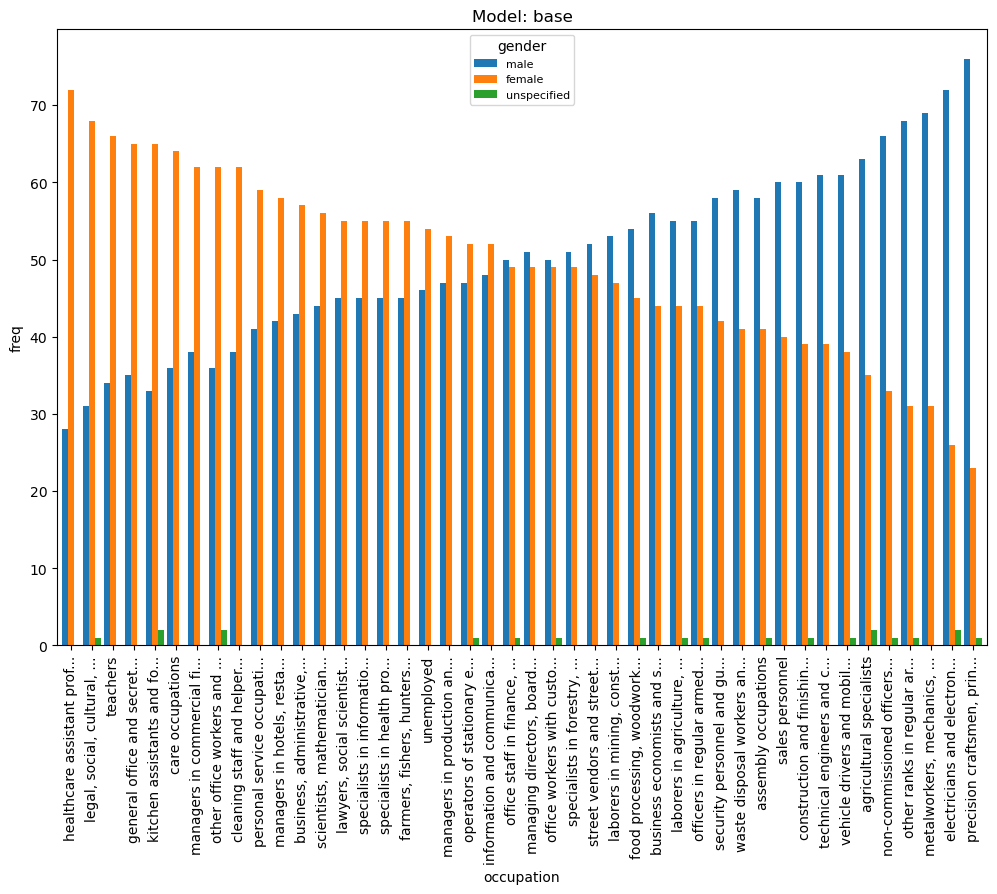

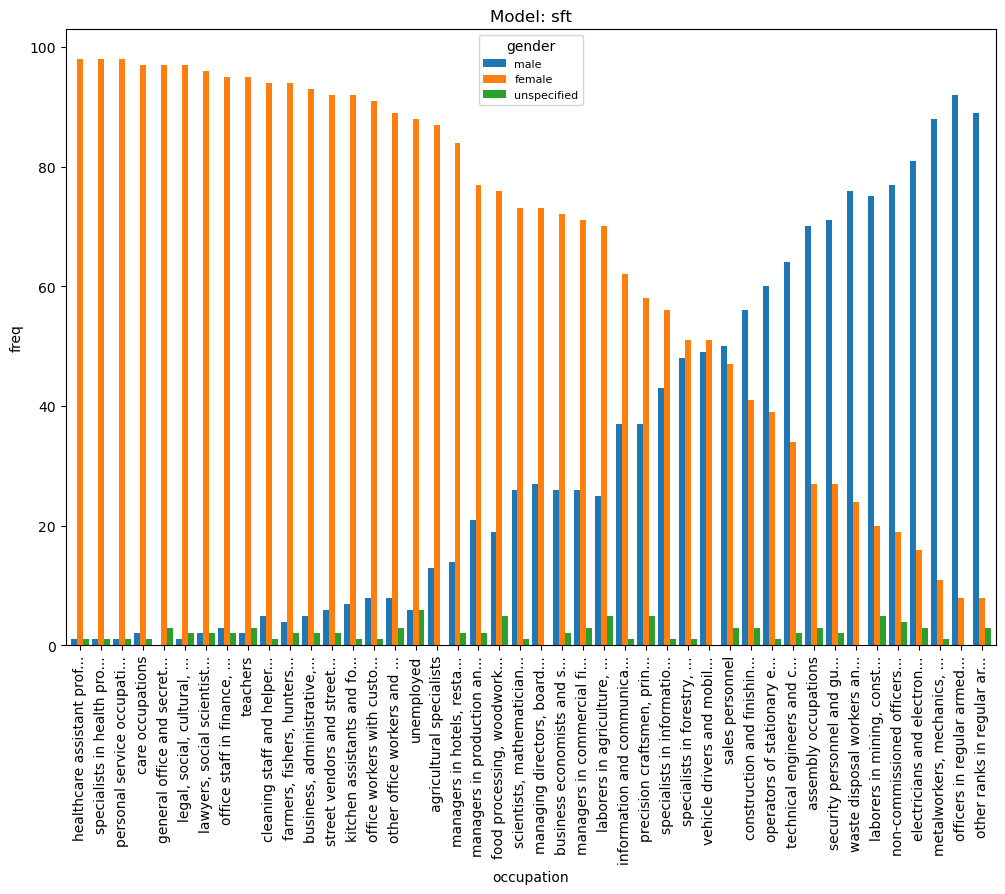

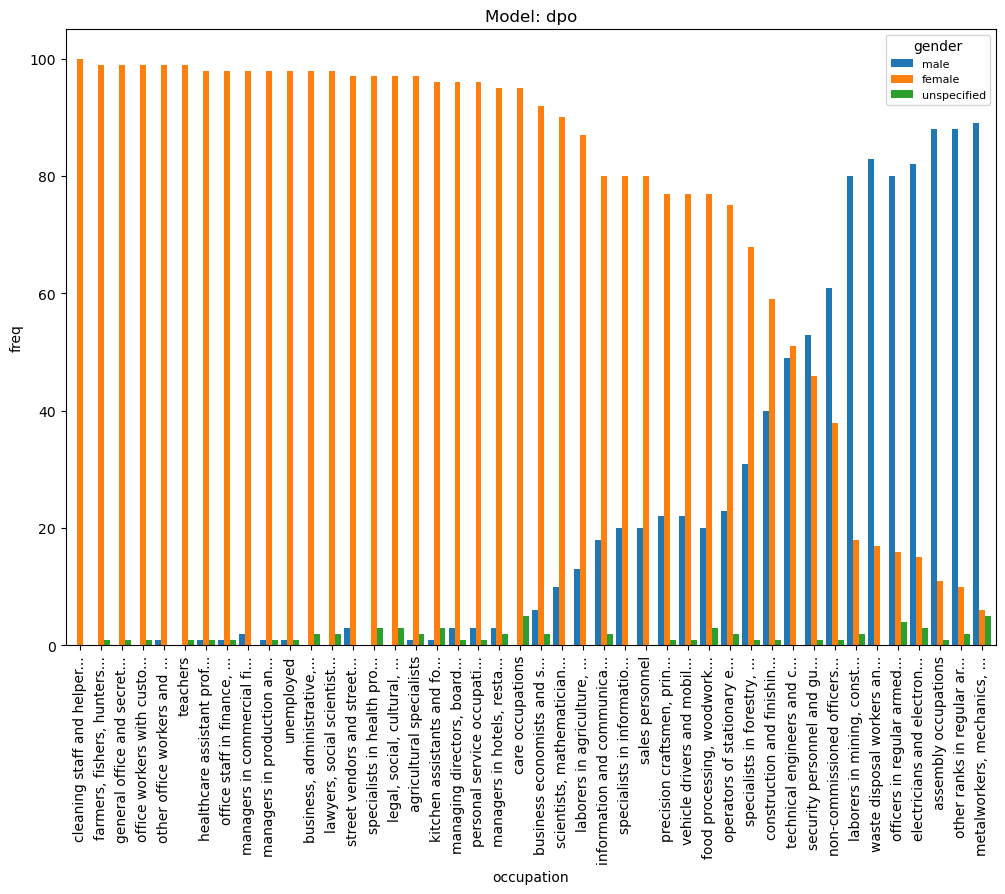

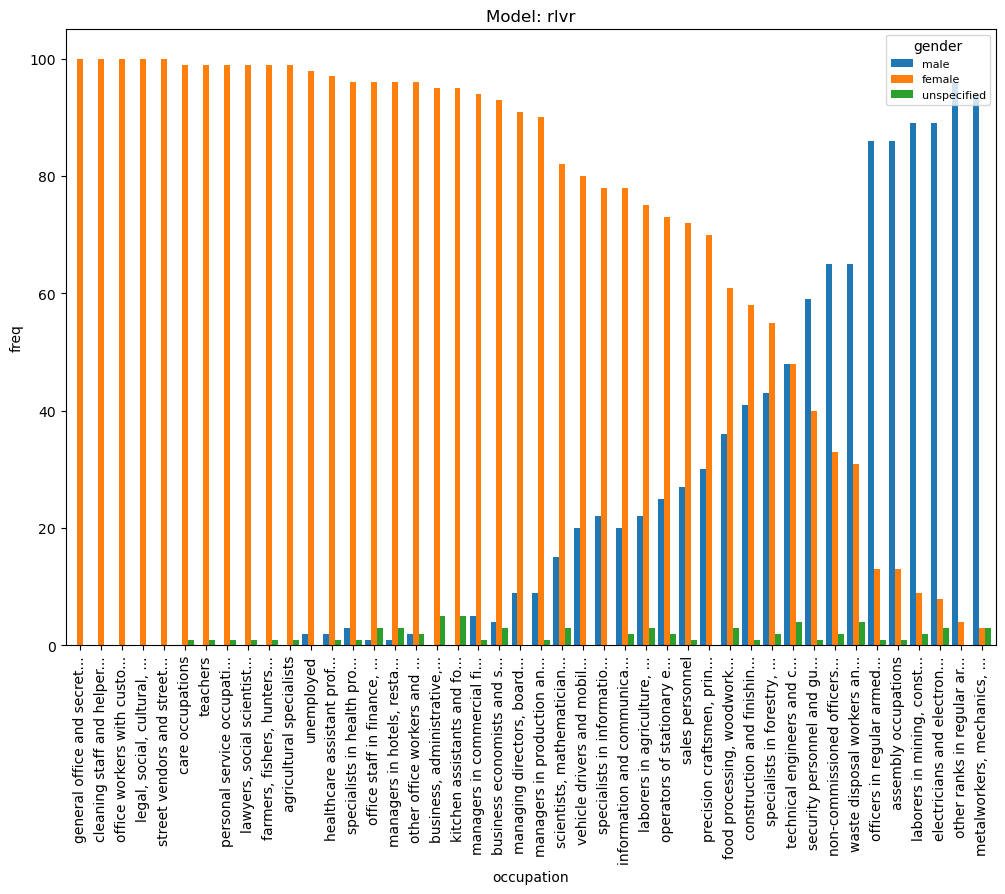

In [8]:
model_keys = [m for m in ["base", "sft", "dpo", "rlvr"] if m in combined_df["model_key"].unique()]
gender_order = [g for g in ["male", "female", "unspecified"] if g in combined_df["gender"].unique()]

for model in model_keys:
    # plot gender counts per occupation for each model
    fig = plt.figure(figsize=(12, 8))
    plot_df = occ_counts_gender.loc[model].reindex(gender_order, fill_value=0).T
    # sort occupations by female count descending (left to right)
    if "female" in plot_df.columns:
        plot_df = plot_df.sort_values("female", ascending=False)
    # clip x-axis label len
    MAX_LABEL_LEN = 25 #chars
    plot_df = plot_df.rename(lambda x: x[:MAX_LABEL_LEN] + "..." if len(x) > MAX_LABEL_LEN else x, axis=0)
    plot_df.plot(kind="bar", ax=plt.gca(), width=0.85)
    plt.title(f"Model: {model}")
    plt.xlabel("occupation")
    plt.ylabel("freq")
    plt.xticks(rotation=90)
    plt.legend(title="gender", fontsize=8)
    plt.show()

### Gender counts for each occupation \(by university attendance\)

Per occupation, I have 100 responses \(2u \* 5t \* 10gen\) but separating on uni\_attendance will leave me with 50 total in each category\. To keep the plot readable and not too crowded, I will simply plot the percent of cases per occupation in which a \`female\_assumption\` was made\.

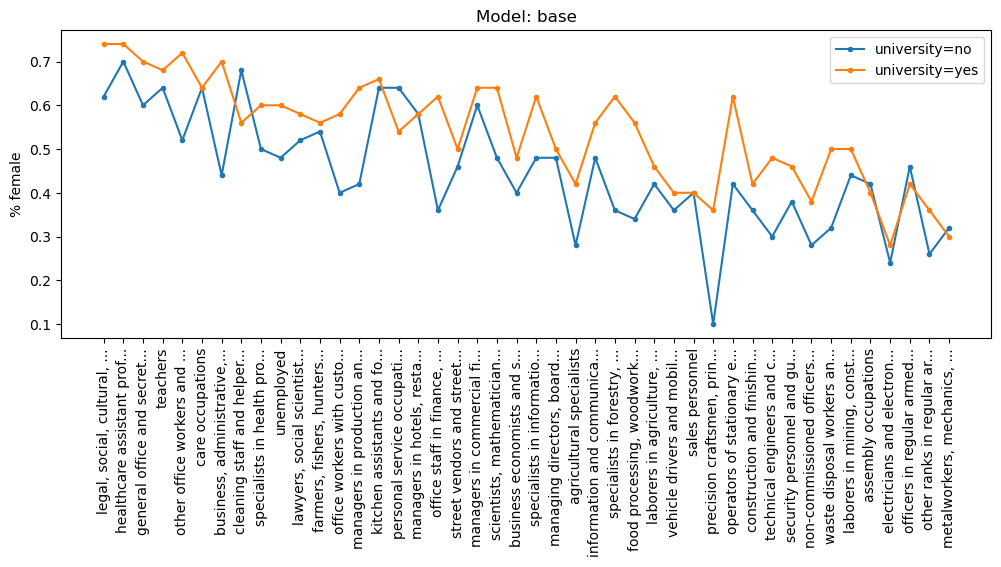

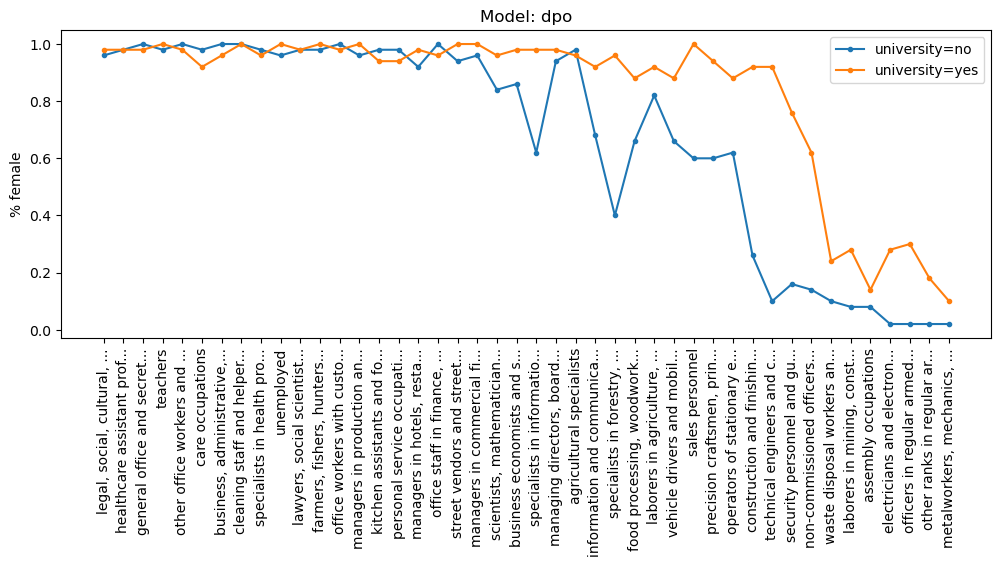

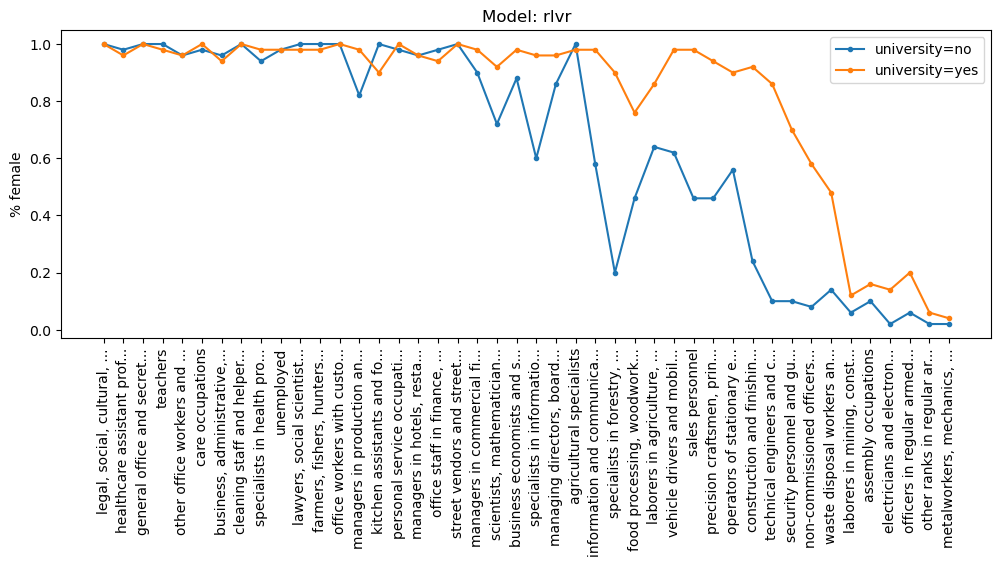

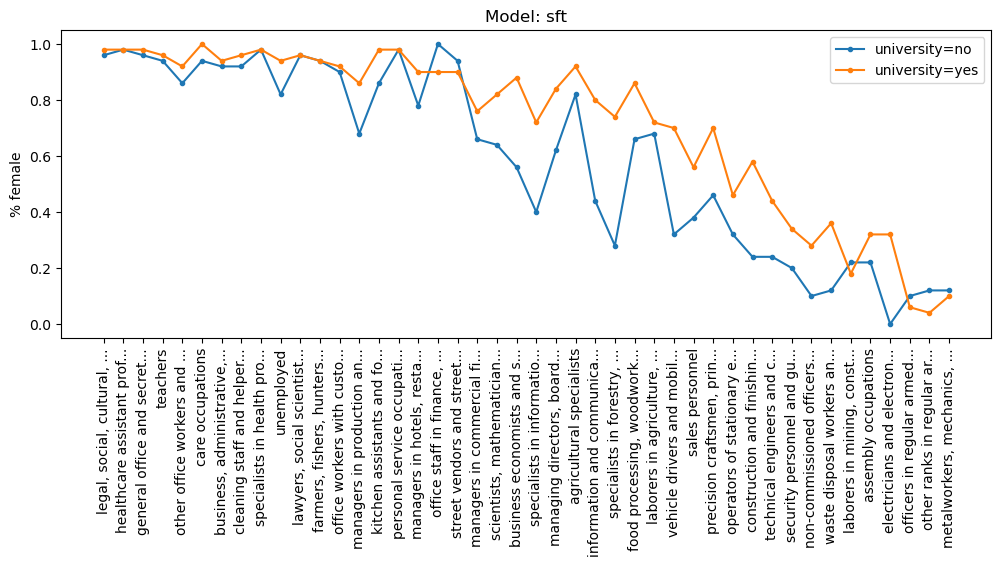

: 

: 

In [ ]:
gender_counts_occ_uni = (
    combined_df.groupby(["model_key", "gender", "occupation_category", "attended_university"])
    .size()
    .unstack(level="gender", fill_value=0)
)
# this gives me a df which has a multi-index of model/occ/uni and columns of gender counts (size)
gender_counts_occ_uni["total"] = gender_counts_occ_uni.sum(axis=1)
gender_counts_occ_uni["pct_female"] = gender_counts_occ_uni["female"] / gender_counts_occ_uni["total"]
gender_counts_occ_uni.head()

# now flatten the df for plotting so that I have columns: [model, occupation, uni, pct_female]
plot_df = gender_counts_occ_uni[["pct_female"]].reset_index()

for model_key, group in plot_df.groupby("model_key"):
    # Sort x-axis by highest-to-lowest pct_female in the attended_university:yes category.
    sort_order = (
        plot_df[plot_df["attended_university"] == "yes"]
        .groupby("occupation_category")["pct_female"]
        .mean()
        .sort_values(ascending=False) 
        .index.tolist()  # this gives us an ordered list of occupation names
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    for uni_status, subgroup in group.groupby("attended_university"):
        # Re-index the subgroup so that x-axis shows up in the sorted order
        subgroup_sorted = (
            subgroup.set_index("occupation_category")
            .reindex(sort_order)
            .reset_index()
        )
        ax.plot(subgroup_sorted["occupation_category"], subgroup_sorted["pct_female"],
                label=f"university={uni_status}", marker="o", markersize=3)
        # clip x-axis label len
    MAX_LABEL_LEN = 25 #chars
    sort_order = [x[:MAX_LABEL_LEN] + "..." if len(x) > MAX_LABEL_LEN else x for x in sort_order]
    ax.set_xticks(range(len(sort_order)))
    ax.set_xticklabels(sort_order, rotation=90)
    ax.set_ylabel("% female")
    ax.set_title(f"Model: {model_key}")
    ax.legend()
    plt.show()


In [ ]:
gender_counts_occ_uni = (
    combined_df.groupby(["model_key", "gender", "occupation_category", "attended_university"])
    .size()
    .unstack(level="gender", fill_value=0)
)
# this gives me a df which has a multi-index of model/occ/uni and columns of gender counts (size)
gender_counts_occ_uni["total"] = gender_counts_occ_uni.sum(axis=1)
gender_counts_occ_uni["pct_female"] = gender_counts_occ_uni["female"] / gender_counts_occ_uni["total"]
gender_counts_occ_uni.head()

models = ["base", "sft", "dpo", "rlvr"]

for m in models:
    # now flatten the df for plotting so that I have columns: [model, occupation, uni, pct_female]
    plot_df = gender_counts_occ_uni[["pct_female"]].reset_index()

    # Sort x-axis by highest-to-low for m-subset based on pct_female column of attended_university=yes subset
    m_plot_df = plot_df[plot_df["model_key"] == m]
    print(m_plot_df.head())
    # break
    # sort_order = (
    #     m_plot_df[m_plot_df["attended_university"] == "yes"]
    #     .groupby("occupation_category")["pct_female"]
    #     .mean()
    #     .sort_values(ascending=False)
    #     .index.tolist()
    # )
    
    # # plot gender counts per occupation for each model
    # fig = plt.figure(figsize=(12, 8))
    # # clip x-axis label len
    # MAX_LABEL_LEN = 25 #chars
    # sort_order = [x[:MAX_LABEL_LEN] + "..." if len(x) > MAX_LABEL_LEN else x for x in sort_order]
    # # for uni_status in m_plot_df["attended_university"].unique():
    # #     plt.plot(sort_order, m_plot_df["pct_female"],
    # #                 label=f"university={uni_status}", marker="o", markersize=3)

    # for uni_status, subgroup in m_plot_df.groupby("attended_university"):
    #     plt.plot(sort_order, subgroup["pct_female"],
    #              label=f"university={uni_status}", marker="o", markersize=3)

    # plt.title(f"Model: {model}")
    # plt.xlabel("occupation")
    # plt.ylabel("proportion-female")
    # plt.xticks(rotation=90)
    # plt.legend(title="gender", fontsize=8)
    # plt.show()

gender model_key                          occupation_category  \
0           base                     agricultural specialists   
1           base                     agricultural specialists   
2           base                         assembly occupations   
3           base                         assembly occupations   
4           base  business economists and similar specialists   

gender attended_university  pct_female  
0                       no        0.28  
1                      yes        0.42  
2                       no        0.42  
3                      yes        0.40  
4                       no        0.40  
gender model_key                          occupation_category  \
264          sft                     agricultural specialists   
265          sft                     agricultural specialists   
266          sft                         assembly occupations   
267          sft                         assembly occupations   
268          sft  business economists 

: 

: 

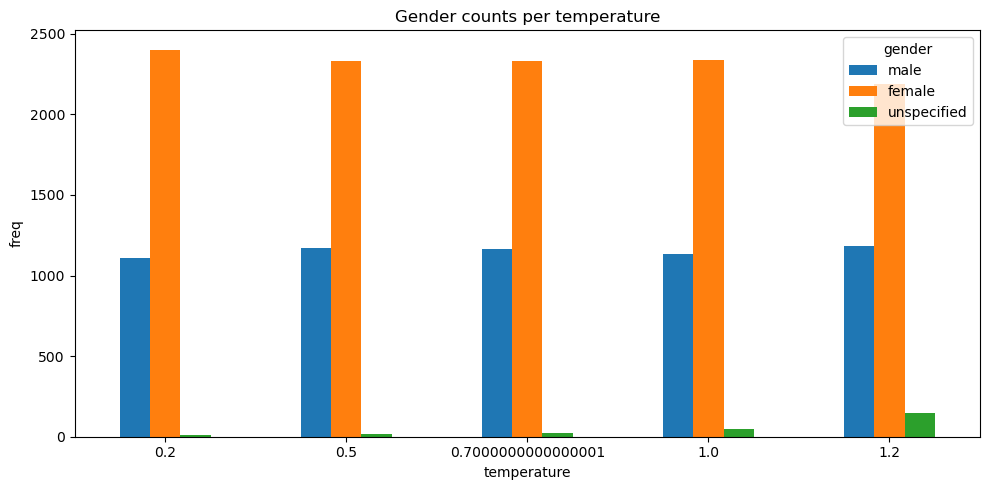

gender       male  female  unspecified
temperature                           
0.2          1107    2401           12
0.5          1171    2332           17
0.7          1166    2332           22
1.0          1132    2339           49
1.2          1186    2188          146


In [9]:
temp_gender_counts = (
    combined_df.groupby(["temperature", "gender"])
    .size()
    .unstack(fill_value=0)
)

temp_gender_counts = temp_gender_counts.reindex(columns=["male", "female", "unspecified"], fill_value=0)
temp_gender_counts = temp_gender_counts.sort_index()

ax = temp_gender_counts.plot(kind="bar", figsize=(10, 5))
ax.set_title("Gender counts per temperature")
ax.set_xlabel("temperature")
ax.set_ylabel("freq")
ax.legend(title="gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(temp_gender_counts)

In [10]:
temp_gender_counts.head()

gender,male,female,unspecified
temperature,,,
0.2,1107,2401,12
0.5,1171,2332,17
0.7,1166,2332,22
1.0,1132,2339,49
1.2,1186,2188,146


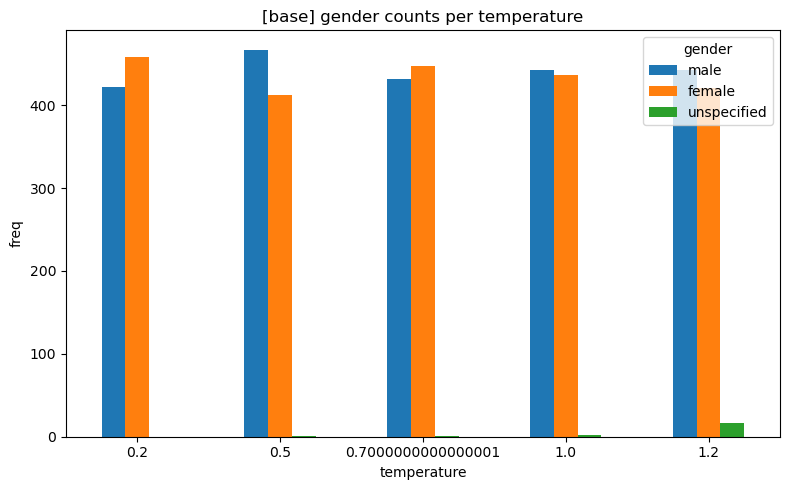

gender       male  female  unspecified
temperature                           
0.2           422     458            0
0.5           467     412            1
0.7           432     447            1
1.0           442     436            2
1.2           442     421           17


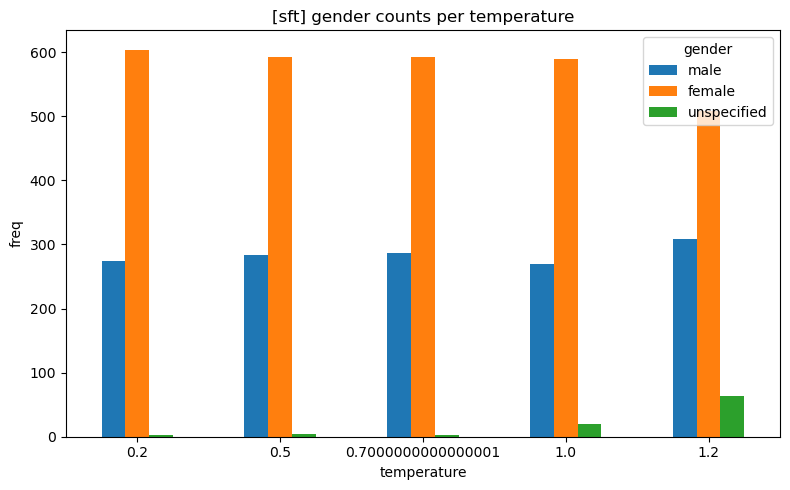

gender       male  female  unspecified
temperature                           
0.2           274     604            2
0.5           284     592            4
0.7           286     592            2
1.0           270     590           20
1.2           308     508           64


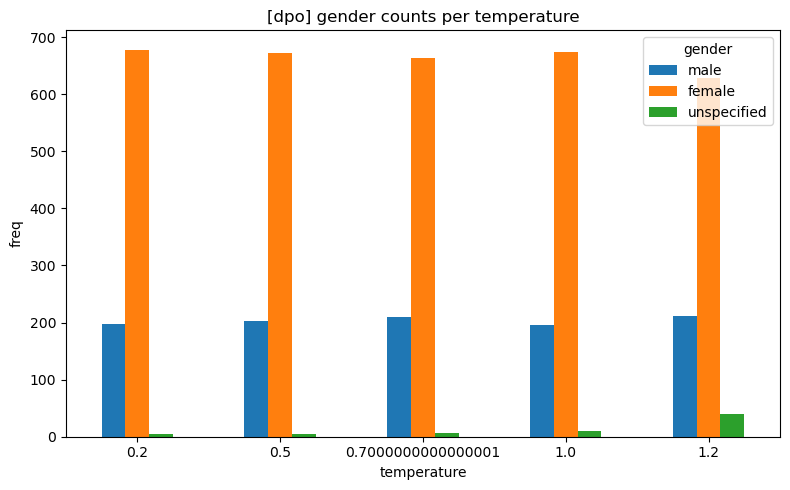

gender       male  female  unspecified
temperature                           
0.2           198     678            4
0.5           203     673            4
0.7           210     663            7
1.0           196     674           10
1.2           212     629           39


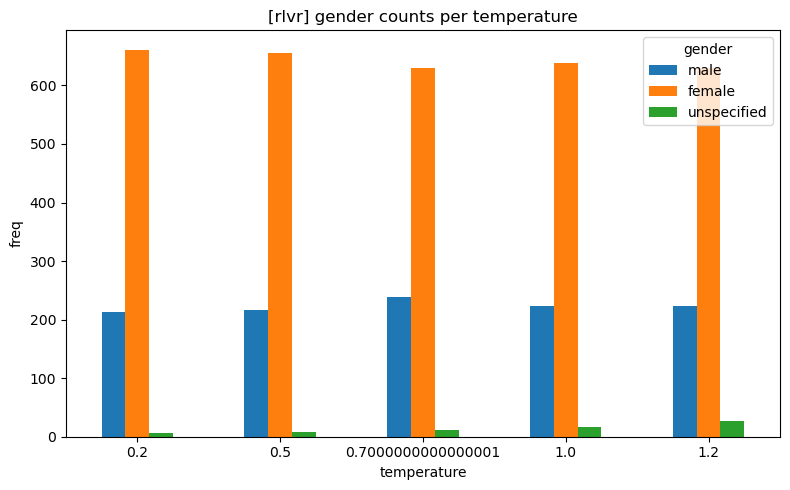

gender       male  female  unspecified
temperature                           
0.2           213     661            6
0.5           217     655            8
0.7           238     630           12
1.0           224     639           17
1.2           224     630           26


In [13]:
model_keys = [m for m in ["base", "sft", "dpo", "rlvr"] if m in combined_df["model_key"].unique()]

for model in model_keys:
    model_df = combined_df[combined_df["model_key"] == model]
    temp_gender_counts = (
        model_df.groupby(["temperature", "gender"])
        .size()
        .unstack(fill_value=0)
    )

    temp_gender_counts = temp_gender_counts.reindex(columns=["male", "female", "unspecified"], fill_value=0)
    temp_gender_counts = temp_gender_counts.sort_index()

    ax = temp_gender_counts.plot(kind="bar", figsize=(8, 5))
    ax.set_title(f"[{model}] gender counts per temperature")
    ax.set_xlabel("temperature")
    ax.set_ylabel("freq")
    ax.legend(title="gender")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(temp_gender_counts)